# Linear regression and gradient descent

In [18]:
from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score


**Standard linear regression** looks like this:
$$y = kx + b$$
**In more advanced quadratic forms** $y = kx^2+bx+c$ etc.

---

**In Data Science**, the more common convention is:
$$h(x) = w_0 + w_1x, \space where$$
- $w_1$ - trainable weight of a feature
- $w_0$ - trainable *bias*
- $x$ - an input feature

**In more complex forms in Data Science** (for $n$ trainable parameters):
$$h(x) = w_0 + \sum_{i=1}^n{w_ix_i}, \space where$$
- $n$ is the number of features
- $w_1, ... w_n$ - a vector of $n$ trainable weights
- $x_1, ... x_n$ - a matrix of input features
- $w_0$ - trainable *bias*

**In complex matrix form in Data Science** (for multidimensional spaces and computation efficiency):
$$h(x) = Xw, \space where$$
- $X$ - input features' matrix with an additional dummy features of $1$s in order to properly multiply the matrices
- $w$ - trainable weights vector

The matrix multiplication itself still preserves the sum of the products mechanism:

- $Xw = \begin{bmatrix} 1 & x_{1,1} & x_{1,2} & \dots & x_{1,n} \\ 1 & x_{2,1} & x_{2,2} & \dots & x_{2,n} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_{m,1} & x_{m,2} & \dots & x_{m,n} \end{bmatrix} \begin{bmatrix} w_0 \\ w_1 \\ w_2 \\ \vdots \\ w_n \end{bmatrix} = \begin{bmatrix} (1 \cdot w_0) + (x_{1,1} \cdot w_1) + (x_{1,2} \cdot w_2) + \dots + (x_{1,n} \cdot w_n) \\ (1 \cdot w_0) + (x_{2,1} \cdot w_1) + (x_{2,2} \cdot w_2) + \dots + (x_{2,n} \cdot w_n) \\ \vdots \\ (1 \cdot w_0) + (x_{m,1} \cdot w_1) + (x_{m,2} \cdot w_2) + \dots + (x_{m,n} \cdot w_n) \end{bmatrix}=\begin{bmatrix} pred_0 \\ pred_1 \\ \dots \\ pred_m \end{bmatrix},\space where$ 
- $n$ is the number of features
- $m$ - number of samples. 
- One element $x_{mn}$ means "an $m$-th value of feature $n$.
- The col of $1$s added to properly multiply features because of the *bias* present

---

In [2]:
def add_np_ones_col(matrix: np.ndarray):
    np_ones = np.ones((matrix.shape[0], 1))
    return np.concatenate((np_ones, matrix), axis=1)

# напишіть функцію гіпотези лінійної регресії у векторному вигляді
def linear_forward_pass(features_matrix: np.ndarray, weights_col: np.ndarray):
    return features_matrix @ weights_col

# створіть функцію для обчислення функції втрат у векторному вигляді
def mse_loss(predictions: np.ndarray, ground_truth: np.ndarray):
    return (1/2) * np.sum((predictions - ground_truth)**2)/len(predictions)

def r2_score_custom(predictions: np.ndarray, ground_truth: np.ndarray):
    # 1. Total variation: how much the actual data spreads around its own mean
    var_mean = np.sum((ground_truth - np.mean(ground_truth)) ** 2)

    # 2. Residual variation: how much the actual data spreads around the regression line
    var_line = np.sum((ground_truth - predictions) ** 2)
    return 1 - (var_line / var_mean)

$$J(w) = \frac{1}{2n} * \sum_{i=1}^n{(\hat y_i-y_i)^2} \space (MSE), \space where$$
- $\frac{1}{2}$ is a coefficient to cancel out the future derivative's factor of 2. Given deep networks, by cancelling out $\frac{1}{2} \cdot \frac{2}{1}$, we eliminate billions of additional multiplications + omit dealing with numbers twice as huge, which helps the optimization problem of minimization. Without it, we would also have to cut our learning rate in half, and it would still be less efficient anyway.
- $n$: number of samples, $\frac{1}{n}$ makes it "error per point"
- $\hat y_i$: $i$-th prediction, **or in other words**: $\hat y_i = w_0 + \sum_{i=1}^n{w_i x_i}$ (forward pass)
- $y_i$: $i$-th ground truth

Now, in order to find the rate of change of our <u>loss</u> with respect to <u>weights</u> using chain rule, we need to find the partial derivative:

$$J(w) = \frac{\partial J(w)}{\partial w}=\frac{\partial [\frac{1}{2n}\sum_{i=1}^n{(\hat y_i-y_i)^2}]}{\partial w}$$

Substitute $\hat y_i$ for the forward pass where the variable $w$ is explicitly present in order to differentiate with respect to it:

$$\begin{gather}
J(w)=\frac{\partial [\frac{1}{2n}\sum_{i=1}^n{\left[(w_ix_i+w_0)-y_i\right]^2}]}{\partial w}=\frac{1}{2n}\sum_{i=1}^n{\underbrace{2(w_ix_i+w_0-y_i)}_{\text{outer derivative}} \cdot \underbrace{\frac{\partial(w_ix_i+w_0-y_i)}{\partial w_i}}_{\text{inner derivative (chain rule)}}}=\frac{2}{2n}\sum_{i=1}^n{(w_ix_i+w_0-y_i)(x_i+0-0)}=
\\
=\frac{1}{n}\sum_{i=1}^n{x_i(w_ix_i+w_0-y_i)}
\end{gather}$$

Substitute back:
$$\nabla J(w) = \frac{1}{n}\sum_{i=1}^n{x_i(\hat y_i-y_i)}$$

In order to vectorize it, we need to transpose to align the $i$-th error with the $i$-th feature across all samples (in order for the shapes to allow multiplication):
$$\nabla J(w) = \frac{1}{n}X^T(\hat y-y)$$

In [3]:
def mse_loss_der(features: np.ndarray, predictions: np.ndarray, ground_truth: np.ndarray):
    n = len(predictions)
    return (1/n) * features @ (predictions - ground_truth)

# реалізуйте один крок градієнтного спуску
def grad(lr: float, loss_der: Callable, features: np.ndarray, predictions: np.ndarray, ground_truth: np.ndarray):
    return lr * loss_der(features, predictions, ground_truth)

In [30]:
rng = np.random.default_rng(seed=42)
noise = rng.normal(loc=0.0, scale=0.5, size=(15, 1))

X = rng.uniform(low=1, high=15, size=(15, 3))
true_w = np.array([[2.5], [-1.2], [0.8]]) # The pattern the model must find
y = (X @ true_w) + 5.0 + noise            # y now perfectly depends on X

In [5]:
# n_fold determines the equal parts to split the dataset into
# 1 part will be used for validation and n_fold-1 parts for training
def cross_validation(n_folds: int, features: np.ndarray, target: np.ndarray):
    len_features = len(features)

    if len_features % n_folds != 0:
        err = f"Can't divide {len_features} by {n_folds} evenly. Please, change 'n_folds' or trim the data"
        raise ValueError(err)

    samples_per_fold = len_features // n_folds
    for i in range(n_folds):
        val_start_idx = i*samples_per_fold
        val_end_idx = i*samples_per_fold+samples_per_fold

        val_target = target[val_start_idx:val_end_idx]
        val_features = features[val_start_idx:val_end_idx]

        train_target = np.concatenate((target[:val_start_idx], target[val_end_idx:]), axis=0)
        train_features = np.concatenate((features[:val_start_idx], features[val_end_idx:]), axis=0)

        yield train_features, val_features, train_target, val_target

In [31]:
def train(lr: float, epochs: int, x_train: np.ndarray, y_train: np.ndarray, w_init: np.ndarray):
    w = w_init.copy()
    for epoch in range(epochs):
        y_hat = linear_forward_pass(x_train, w)
        gradients = grad(lr, mse_loss_der, x_train.T, y_hat, y_train)
        w = w - gradients

    y_hat = linear_forward_pass(x_train, w)
    mse = mse_loss(y_hat, y_train)
    rmse = np.sqrt(mse)
    r2 = r2_score_custom(y_hat, y_train)
    print(f"(train) MSE = {mse}")
    print(f"(train) RMSE = {rmse}")
    print(f"(train) R2 = {r2}")
    print()

    return w, mse, rmse, r2

def validate(x_valid, y_valid, w):
    y_hat = linear_forward_pass(x_valid, w)
    mse = mse_loss(y_hat, y_valid)
    rmse = np.sqrt(mse)
    r2 = r2_score_custom(y_hat, y_valid)
    print(f"(validation) MSE = {mse}")
    print(f"(validation) RMSE = {rmse}")
    print(f"(validation) R2 = {r2}")
    print()

    return mse, rmse, r2

In [38]:
# constants
RANDOM_SEED = 42
LR = 1e-5
N_FOLDS = 3
EPOCHS = 1000

# init weights
w_init = rng.uniform(low=1e-6, high=1e-5, size=(4, 1))
X_modified = add_np_ones_col(X) # to account for w_0 (bias)

train_mses, train_rmses, train_r2s = [], [], []
valid_mses, valid_rmses, valid_r2s = [], [], []
for i, (train_features, val_features, train_target, val_target) in enumerate(cross_validation(n_folds=N_FOLDS, features=X_modified, target=y)):
    print(f"Fold {i+1}")
    w_fold = w_init.copy()
    # do not update weights during cross-validation
    w_trained, train_mse, train_rmse, train_r2 = train(LR, EPOCHS, train_features, train_target, w_fold)
    train_mses = np.append(train_mses, train_mse)
    train_rmses = np.append(train_rmses, train_rmse)
    train_r2s = np.append(train_r2s, train_r2)

    valid_mse, valid_rmse, valid_r2 = validate(val_features, val_target, w_trained)
    valid_mses = np.append(valid_mses, valid_mse)
    valid_rmses = np.append(valid_rmses, valid_rmse)
    valid_r2s = np.append(valid_r2s, valid_r2)
    print("--------------")

print("----- Finished -----")
print(f"Train MSE = {np.mean(train_mses)}")
print(f"Train RMSE = {np.mean(train_rmses)}")
print(f"Train R2 = {np.mean(train_r2s)}")
print()
print(f"Validation MSE = {np.mean(valid_mses)}")
print(f"Validation RMSE = {np.mean(valid_rmses)}")
print(f"Validation R2 = {np.mean(valid_r2s)}")

Fold 1
(train) MSE = 45.63938026925882
(train) RMSE = 6.75569243447767
(train) R2 = 0.2610947734443594

(validation) MSE = 41.50775432781382
(validation) RMSE = 6.4426511878118795
(validation) R2 = 0.4340075298716969

--------------
Fold 2
(train) MSE = 52.9769665949859
(train) RMSE = 7.2785277766170475
(train) R2 = 0.229920405441022

(validation) MSE = 25.512820010141137
(validation) RMSE = 5.051021679832817
(validation) R2 = 0.576935203675589

--------------
Fold 3
(train) MSE = 35.43479321965552
(train) RMSE = 5.952713097374635
(train) R2 = 0.4706884718103289

(validation) MSE = 86.2783650870723
(validation) RMSE = 9.288614809920384
(validation) R2 = -0.3777075521349307

--------------
----- Finished -----
Train MSE = 44.68371336130008
Train RMSE = 6.662311102823117
Train R2 = 0.32056788356523674

Validation MSE = 51.09964647500908
Validation RMSE = 6.927429225855026
Validation R2 = 0.21107839380411844


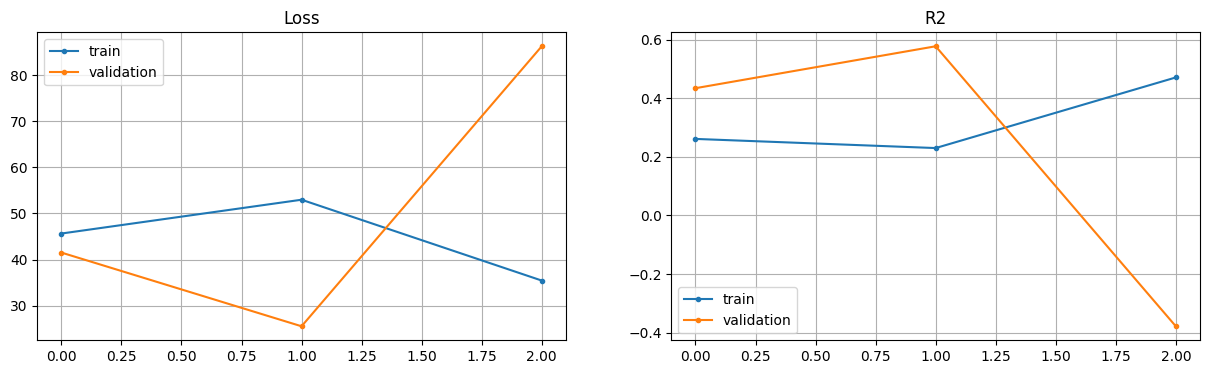

In [39]:
def plot_loss_acc_per_ep(train_losses, valid_losses, train_r2, valid_r2s):
    _, axes = plt.subplots(ncols=2, figsize=(15, 4))

    axes[0].plot(np.arange(len(train_losses)), train_losses, ".-")
    axes[0].plot(np.arange(len(valid_losses)), valid_losses, ".-")
    axes[0].legend(["train", "validation"])
    axes[0].set_title("Loss")
    axes[0].grid()

    axes[1].plot(np.arange(len(train_r2)), train_r2, ".-")
    axes[1].plot(np.arange(len(valid_r2s)), valid_r2s, ".-")
    axes[1].legend(["train", "validation"])
    axes[1].set_title("R2")
    axes[1].grid()

plot_loss_acc_per_ep(train_mses, valid_mses, train_r2s, valid_r2s)

## Analytical solution